In [1]:
#Impot libraries
import pathlib
import os
import datetime

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:128"

import torch
from torch.utils.tensorboard.writer import SummaryWriter
import trimesh
from pytorch3d.loss import chamfer_distance

import utils, dataset, train, visualization
from encoder import *
from decoder import *

%load_ext autoreload
%autoreload 2

/home/nikola/miniconda3/envs/adlr/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
# Model name
current_time = datetime.datetime.now().strftime("%b%d_%H-%M")
denoiser_name = "8_Objects_500timestep_100epochs_16batch_KL0.001_hidden_dec128_time_emb"
experiment_name = f"{current_time}_{denoiser_name}"


config = {
    'experiment_name': experiment_name,
    'device': 'cuda:0',
    'batch_size': 16,
    'resume_ckpt': None,
    'learning_rate': 0.0004,
    'step_size': 10, # scheduler step, one step is one batch
    'gamma': 1,
    'max_epochs': 100,
    'timesteps': 500,
    'print_every_n': 25, # every n batches
    # 'validate_every_n': 10,
    # 'print_EMD_every_n': 1
}

model_config = {
    'last_epoch': 0,
    'enc_hidden_channels': 64,
    'dec_hidden_dim': 128,
    'latent_dim': 32
}

In [3]:
# declare device
if torch.cuda.is_available() and config['device'].startswith('cuda'):
    device = torch.device(config['device'])
    print('Using device:', config['device'])
else:
    device = torch.device('cpu')
    print('Using CPU')

# create dataloaders
trainset = dataset.Dataset('overfit', config['timesteps'])
trainloader = torch.utils.data.DataLoader(trainset, batch_size=config['batch_size'], shuffle=True, num_workers=0, pin_memory=False)
# valset = dataset.Dataset('val', config['timesteps'])
# valloader = torch.utils.data.DataLoader(valset, batch_size=config['batch_size'], shuffle=False, num_workers=0)

encoder = Encoder(number_points=2048, in_channels=3, hidden_channels=model_config['enc_hidden_channels'], latent_dim=model_config['latent_dim'], clamp=False)
decoder = Decoder(number_points=2048, point_dim=3, hidden_dim=model_config['dec_hidden_dim'], latent_dim=model_config['latent_dim'], timesteps=config['timesteps'], beta_start=1e-4, beta_end=0.02)

# move model to specified device
encoder.to(device)
decoder.to(device)
optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=config['learning_rate'])
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, config['step_size'], config['gamma'])
# scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.0006, steps_per_epoch=len(trainloader), epochs=config['max_epochs'], anneal_strategy='cos', three_phase=True)



# load model if resuming from checkpoint
# experiment_name = "May31_17-04_10_Objects_200epochs_32batch"
# utils.reload_model(encoder, decoder, optimizer, None, experiment_name, 'epoch136', device)


total_enc, trainable_enc = utils.count_parameters(encoder)
total_dec, trainable_dec = utils.count_parameters(decoder)
print(f"Encoder Total: {total_enc:,} | Trainable: {trainable_enc:,} | Model size: {utils.model_memory_size(encoder):.3f} MB")
print(f"Decoder Total: {total_dec:,} | Trainable: {trainable_dec:,} | Model size: {utils.model_memory_size(decoder):.3f} MB")

Using device: cuda:0
Encoder Total: 129,216 | Trainable: 129,216 | Model size: 0.493 MB
Decoder Total: 495,238 | Trainable: 495,238 | Model size: 1.899 MB


In [4]:
torch.cuda.empty_cache()

In [6]:
# start training
torch.cuda.empty_cache()
#tensorboard --logdir=diffusion_autoencoder/logs
# config['max_epochs'] = 200
# Create tensorboard writer    
log_path = pathlib.Path(f"logs/{datetime.datetime.now().strftime('%b%d')}/{config['experiment_name']}")
writer = SummaryWriter(log_path)

with open("debug.txt", "w", encoding="utf-8") as debug_file:
    train.train(encoder, decoder, trainloader, None, device, optimizer, scheduler, config, model_config, writer, None, debug_file)

writer.close()


[00/024] train_loss: 1.150
Best Model:   1.1375684216618538
[01/017] train_loss: 1.050
Best Model:   0.9448091182857752
[02/010] train_loss: 0.722
Best Model:   0.41622427059337497
[03/003] train_loss: 0.322
[03/028] train_loss: 0.259
Best Model:   0.2690117587335408
[04/021] train_loss: 0.247
Best Model:   0.23687605955637991
[05/014] train_loss: 0.220
Best Model:   0.20065447012893856
[06/007] train_loss: 0.195
[07/000] train_loss: 0.224
[07/025] train_loss: 0.206
[08/018] train_loss: 0.214
[09/011] train_loss: 0.224
[10/004] train_loss: 0.210
[10/029] train_loss: 0.217
[11/022] train_loss: 0.212
[12/015] train_loss: 0.199
[13/008] train_loss: 0.209
[14/001] train_loss: 0.214
[14/026] train_loss: 0.232
[15/019] train_loss: 0.223
[16/012] train_loss: 0.221
Best Model:   0.18407908035442233
[17/005] train_loss: 0.185
[17/030] train_loss: 0.212
[18/023] train_loss: 0.200
[19/016] train_loss: 0.191
[20/009] train_loss: 0.212
[21/002] train_loss: 0.176
[21/027] train_loss: 0.186
[22/020] 

In [5]:
#Load a model:
experiment_name = "Jun04_23-47_8_Objects_500timestep_100epochs_16batch_KL0.001_hidden_dec128_time_emb"
_,_,encoder, decoder = utils.reload_model(None, None, experiment_name, 'best', device)

In [ ]:
# Old reload
experiment_name = "Jun04_02-43_3_Objects_50epochs_16batch_KL0.001_hidden_dec128_time_emb"
utils.reload_model_old(encoder, decoder, None, None, experiment_name, 'best', device)

({'experiment_name': 'Jun04_02-43_3_Objects_50epochs_16batch_KL0.001_hidden_dec128_time_emb',
  'device': 'cuda:0',
  'batch_size': 16,
  'resume_ckpt': None,
  'learning_rate': 0.0004,
  'step_size': 10,
  'gamma': 1,
  'max_epochs': 100,
  'timesteps': 1000,
  'print_every_n': 15},
 {'last_epoch': 0})

In [6]:
generateDDIM = 1
generateDDPM = 0
number_of_points = 2048
DDIM_steps = 50
number_of_DDIM_iterations = 1
save = False

if generateDDIM:
    for object_index in range(trainset.real_length):
        for i in range(number_of_DDIM_iterations):
            mean, log_variance = encoder(trainset[object_index].unsqueeze(0))
            code = encoder.sample_latent_z(mean, log_variance)

            generated_pc_ddim = sample_ddim(decoder, code, n_points=number_of_points, steps=DDIM_steps, timesteps=config['timesteps'])
            generated_pcd_ddim = trimesh.PointCloud(generated_pc_ddim.squeeze().cpu().numpy())
            
            dist, _ = chamfer_distance(trainset[object_index].unsqueeze(0), generated_pc_ddim)
            print(f"Chamfer distance, Object{object_index}: {dist}")
            utils.visualize_comparison(trainset[object_index], generated_pc_ddim, window_name="DDIM Target (Red) vs Generated (Blue)")
            
            if save:
                path = pathlib.Path(f"output/{experiment_name}")
                path.mkdir(parents=True, exist_ok=True)
                generated_pcd_ddim.export(path / f"ddim{DDIM_steps}_{number_of_points}_{i}.obj")

if generateDDPM:
        object_index = 0
        mean, log_variance = encoder(trainset[object_index].unsqueeze(0))
        code = encoder.sample_latent_z(mean, log_variance)
        generated_pc_ddim = sample_ddpm(decoder, code, n_points=number_of_points, timesteps=config['timesteps'])
        generated_pcd_ddim = trimesh.PointCloud(generated_pc_ddim.squeeze().cpu().numpy())
        utils.visualize_comparison(trainset[object_index], generated_pc_ddim, window_name="DDIM Target (Red) vs Generated (Blue)")

Chamfer distance, Object0: 0.004481570795178413
Chamfer distance, Object1: 0.017571816220879555
Chamfer distance, Object2: 0.007703423500061035
Chamfer distance, Object3: 0.020527837797999382
Chamfer distance, Object4: 0.012943502515554428
Chamfer distance, Object5: 0.010046505369246006
Chamfer distance, Object6: 0.010257500223815441
Chamfer distance, Object7: 0.004833531565964222


Object 0: 0.051 ; [-0.54, -0.0, -0.25, -0.31, 0.6, 0.01, 0.59, 0.28, -0.57, 0.24, -0.41, -0.3, 0.18, -1.49, -0.9, 1.13, -0.23, -0.28, -0.58, 0.11, 1.53, -0.15, -0.03, 0.18, -0.29, 0.44, -0.2, 0.77, 0.73, 0.67, 0.67, 0.02]
Object 1: -0.015 ; [0.94, -0.15, 0.23, -0.24, -0.32, -0.73, 0.21, 0.2, 0.55, -1.26, -1.29, -1.17, 1.02, -0.92, -1.11, 0.08, 0.06, 0.01, 0.24, 0.35, 0.52, -0.42, -0.28, 0.09, -0.14, -1.29, 0.76, 1.1, 0.29, 1.12, 1.14, -0.05]
Object 2: -0.036 ; [-0.23, 0.05, 0.66, -0.07, 0.19, -0.67, 0.84, 0.19, 0.73, 0.15, -1.45, 0.07, 0.28, -1.01, -1.37, 0.9, -0.72, 0.18, 0.01, 0.83, -0.93, 0.15, -0.22, 0.69, 0.17, -0.87, 1.02, -0.89, 0.26, -0.11, -0.29, 0.27]
Object 3: 0.094 ; [0.29, -0.07, 0.93, 0.02, 0.1, -0.78, 0.38, 0.05, -0.24, -0.86, -0.9, -0.52, 0.84, -1.6, -0.4, 0.42, 0.34, 0.29, 0.25, -0.28, 1.91, -0.48, -0.76, 0.22, -0.31, -1.14, 0.66, 2.03, 0.06, 1.07, 0.89, 0.58]
Object 4: -0.090 ; [-0.5, -0.37, 0.12, -0.01, 0.72, -1.16, 0.81, 0.04, -0.06, -0.07, -1.03, 0.4, 0.14, -0.65, 

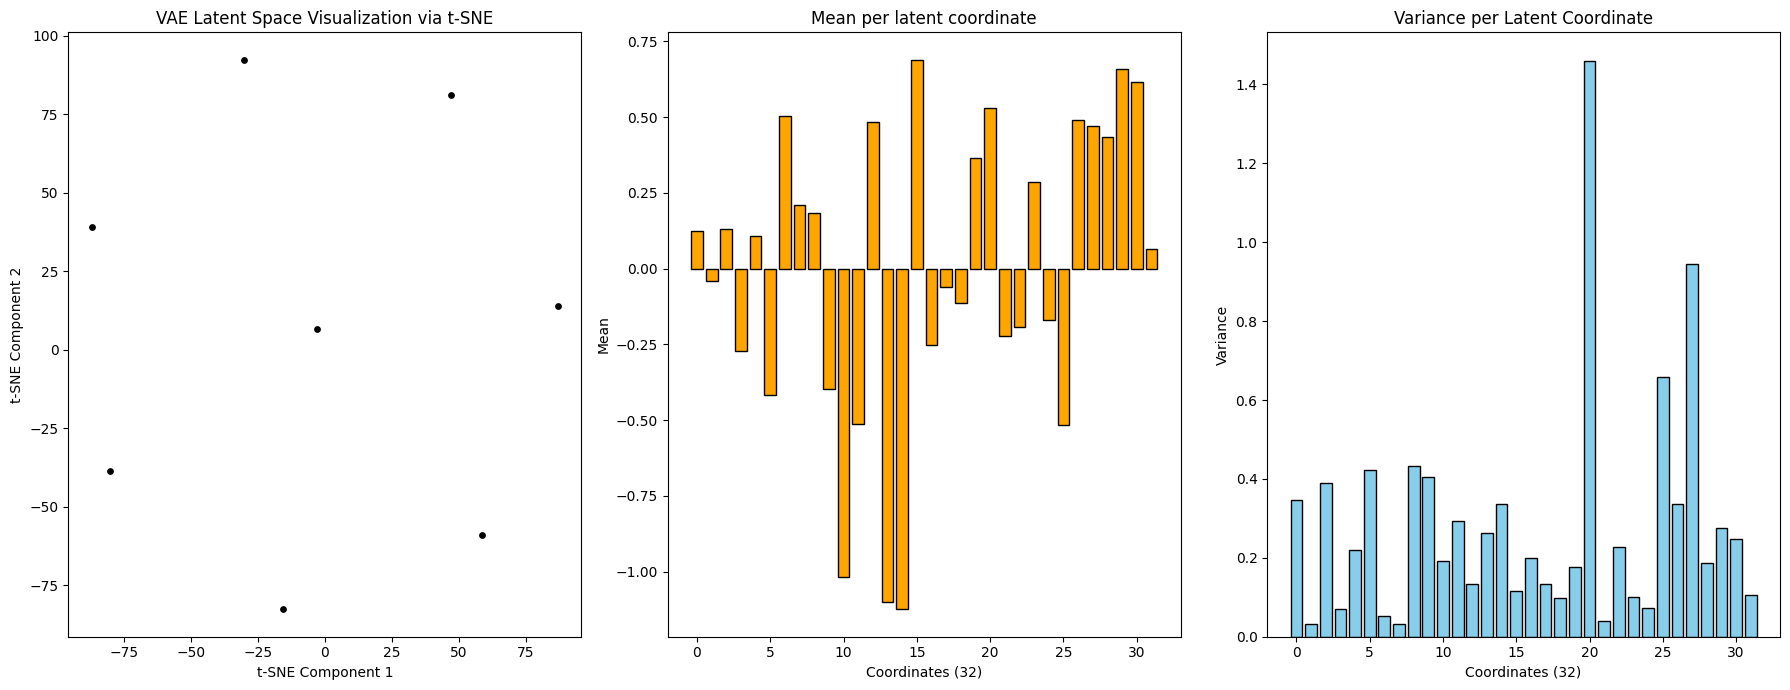

In [ ]:
# VAE latent space visualization
import torch
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 1. Extract latent representations
encoder.eval()
all_latents = []
all_labels = []
mean_matrix = torch.zeros([trainset.real_length, model_config['latent_dim']])

with torch.no_grad():
    for index in range(trainset.real_length):
        data = trainset[index]
        data = data.to(device)
        mu, _ = encoder(data.unsqueeze(0)) 
        mu_list = mu.squeeze().tolist()

        mean_matrix[index] = mu.squeeze(0)
        formatted_dims = [f"{val:.2f}" for val in mu_list]  # Fixed typo from .2 to .2f
        mu_list = [float(x) for x in formatted_dims]
        print(f"Object {index}: {mu.mean():.3f} ; {mu_list}")
        all_latents.append(mu.cpu().numpy())
        all_labels.append(index)

latents = np.concatenate(all_latents, axis=0)
labels = np.array(all_labels)

# 2. Run t-SNE
perplexity = min(30, trainset.real_length - 1)
print(f"\nRunning t-SNE with perplexity={perplexity} for {trainset.real_length} samples.")
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, n_jobs=-1)
latents_2d = tsne.fit_transform(latents)

# Mean calculation
# Variance of the latent space + plotting
mean_per_latent_coord = mean_matrix.mean(dim=0).tolist()
# formatted_list = [f"{x:.2f}" for x in mean_matrix.mean(dim=0).tolist()]
# print("Mean per latent coordinate: ")
# print(formatted_list)

# indices = range(len(mean_per_latent_coord))  # Creates [0, 1, 2, 3, 4, 5]


# 3. Calculate Variance per coordinate 
# Changed .mean(dim=0) to .var(dim=0) to match your variable name and objective!
variance_per_latent_coord = mean_matrix.var(dim=0).tolist()
formatted_list = [f"{x:.2f}" for x in variance_per_latent_coord]
# print("\nVariance per latent coordinate: ")
# print(formatted_list)

indices = range(len(variance_per_latent_coord))

# ==========================================
# 4. SIDE-BY-SIDE PLOTTING
# ==========================================
# Create a figure with 1 row and 2 columns
fig, (ax2, ax3, ax1) = plt.subplots(1, 3, figsize=(18, 7))

# Right Plot: t-SNE Scatter Plot
scatter = ax2.scatter(latents_2d[:, 0], latents_2d[:, 1], color = 'black', s=15)
# fig.colorbar(scatter, ax=ax2, label='Item Index') # Colorbar attached specifically to ax2
ax2.set_title("VAE Latent Space Visualization via t-SNE")
ax2.set_xlabel("t-SNE Component 1")
ax2.set_ylabel("t-SNE Component 2")

ax3.bar(indices, mean_per_latent_coord, color='orange', edgecolor='black')
ax3.set_title('Mean per latent coordinate')
ax3.set_xlabel(f'Coordinates ({model_config["latent_dim"]})')
ax3.set_ylabel('Mean')


# Left Plot: Variance Bar Chart
ax1.bar(indices, variance_per_latent_coord, color='skyblue', edgecolor='black')
ax1.set_xlabel(f'Coordinates ({model_config["latent_dim"]})')
ax1.set_ylabel('Variance')
ax1.set_title('Variance per Latent Coordinate')


# Adjust spacing cleanly and showplt.tight_layout()
plt.show()